<span style="float: left;padding: 1.3em">![logo](../logo.png)</span>

# Gravitational Wave Open Data Workshop

## Tutorial 2: Accessing Open Data with GWpy

This tutorial will briefly describe GWpy, a python package for gravitational astrophysics, and walk-through how you can use this to speed up access to, and processing of, GWOSC data.

View this tutorial on [Google Colaboratory](https://colab.research.google.com/github/gw-odw/odw/blob/main/Tutorials/Accessing_Open_Data/Tuto_2_Open_Data_access_with_GWpy.ipynb) or launch [mybinder](https://mybinder.org/v2/gh/gw-odw/odw/HEAD).


In [1]:
# Those 2 lines are just to avoid some harmless warnings when importing packages
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

## Installation (execute only if running on a cloud platform, like Google Colab, or if you haven't done the installation already!)

> ⚠️ **Warning**: restart the runtime after running the cell below.
>
> To do so, click "Runtime" in the menu and choose "Restart and run all".
>
> You may see error messages but installation usually works.
> If you experience problems, please [report an issue](https://github.com/gw-odw/odw/issues).

In [2]:
# -- Uncomment following line if running in Google Colab
#! pip install -q 'gwpy==3.0.14' 'cryptography==43.0.0'

## Initialization

In [3]:
# The first import of gwpy can take some time (especially on cloud platforms).
# This is mainly due to matplotlib taking some time to import (this is normal).
import gwpy
print(gwpy.__version__)

3.0.12


## A note on object-oriented programming

Before we dive too deeply, it's worth a quick aside on object-oriented programming (OOP).
[GWpy](https://gwpy.readthedocs.io/en/v3.0.13/index.html) is heavily object-oriented, meaning almost all of the code you run using GWpy is based around an object of some type, e.g. `TimeSeries`.
Most of the methods (functions) we will use are attached to an object, rather than standing alone, meaning you should have a pretty good idea of what sort of data you are dealing with (without having to read the documentation!).

For a quick overview of object-oriented programming in Python, see [this blog post by Jeff Knupp](https://medium.com/hackernoon/improve-your-python-python-classes-and-object-oriented-programming-d09ff461168d).

## Handling data in the time domain

#### Finding open data

We have seen already that the `gwosc` module can be used to query for what data are available on [GWOSC](https://gwosc.org/data/).
The next thing to do is to actually read some open data. Let's try to get some for GW190412, the first detection of a gravitational-wave signal from a significantly unequal-mass BBH (binary black hole system).

We can use the [TimeSeries.fetch_open_data](https://gwpy.readthedocs.io/en/v3.0.13/api/gwpy.timeseries.TimeSeries/#gwpy.timeseries.TimeSeries.fetch_open_data) method to download data directly from https://gwosc.org, but we need to know the GPS times.
We can query for the GPS time of an event as follows:

In [4]:
from gwosc.datasets import event_gps
gps = event_gps('GW190412')
print(gps)

1239082262.1


Now we can build a `[start, end)` GPS segment to 10 seconds around this time, using integers for convenience:

In [5]:
segment = (int(gps)-5, int(gps)+5)
print(segment)

(1239082257, 1239082267)


and can now query for the full data.
For this example we choose to retrieve data for the LIGO-Livingston interferometer, using the identifier `'L1'`.
We could have chosen any of

- `'G1'` - GEO600
- `'H1'` - LIGO-Hanford
- `'L1'` - LIGO-Livingston
- `'V1'` - (Advanced) Virgo
- `'K1'` - KAGRA


In [6]:
from gwpy.timeseries import TimeSeries
ldata = TimeSeries.fetch_open_data('L1', *segment, verbose=True)
print(ldata)

Fetched 1 URLs from gwosc.org for [1239082257 .. 1239082267))
Reading data... [Done]
TimeSeries([-8.42597565e-19, -8.52437103e-19, -8.60738804e-19,
            ...,  1.38850270e-19,  1.37760541e-19,
             1.38094202e-19]
           unit: dimensionless,
           t0: 1239082257.0 s,
           dt: 0.000244140625 s,
           name: Strain,
           channel: None)


##### The `verbose=True` flag lets us see that GWpy has discovered one file that provides the data for the given interval, downloaded it, and loaded the data.
The files are not stored permanently, so next time you do the same call, it will be downloaded again, however, if you know you might repeat the same call many times, you can use `cache=True` to store the file on your computer.

Notes: 

* To control the dataset from which your data come from you can use the 'dataset' keyword. It is recommended to use data from a run if they are available, because they contain the most updated version of the calibration. To check which was the run at the time you want to query, it is enough to use the find_datasets method of the package gwosc discussed in the previous tutorial, specifying (`type='run',segment=segment`). For example, for the segment we are using in this tutorial, the two available datasets are [`'O3a_16KHZ_R1'`, `'O3a_4KHZ_R1'`]. For the sampling at 4 kHz, the complete command to get data from this dataset is then: `TimeSeries.fetch_open_data('L1', *segment, verbose=True, dataset='O3a_4KHZ_R1')`.  

* To read data from a local file instead of from the GWOSC server, we can use  [`TimeSeries.read`](https://gwpy.readthedocs.io/en/v3.0.13/api/gwpy.timeseries.TimeSeries/#gwpy.timeseries.TimeSeries.read) method.

We have now downloaded real LIGO data for GW190412! These are the actual data used in the analysis of this binary black hole merger.

To sanity check things, we can easily make a plot, using the [`plot()`](https://gwpy.readthedocs.io/en/v3.0.13/plot/) method of the `data` `TimeSeries`.

<div class="alert alert-info">
Since this is the first time we are plotting something in this notebook, we need to configure `matplotlib` (the plotting library) to work within the notebook properly:
</div>

Matplotlib documentation can be found [here](https://matplotlib.org/stable/users/index.html).

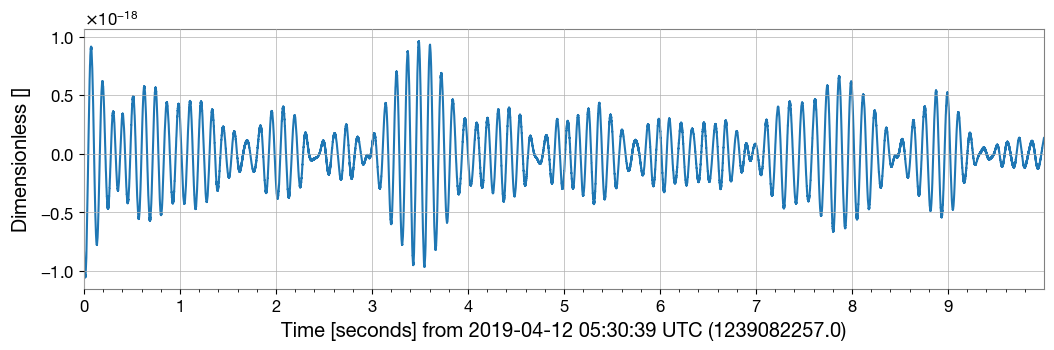

In [7]:
plot = ldata.plot()

# Challenges:

## Quiz Question 1:

Looking at the LIGO-Livingston data in the time domain, the peak amplitude of the gravitational-wave signal of GW190412  occurs at the center of the figure, that is, at approximately 5 seconds from the start of the segment. This peak is undetectable above the background noise by the eye. Plot the data for the LIGO-Hanford detector around GW190412. Looking at your new LIGO-Handford plot, can your eye identify a signal peak? What about Virgo data?

## Quiz Question 2 :

Make an ASD around the time of an O1 event, GW150914 for L1 detector.  Compare this with the ASDs around GW190412 for L1 detector.  Which data have lower noise - and so are more sensitive - around 100 Hz?
